In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
import numpy as np
import matplotlib.pyplot as plt
from moc.metrics.distribution_metrics import pce
import torch
import wandb

In [3]:
import pandas as pd
import plotly.express as px

In [4]:
wandb.login(key="9d338bfb8d6dd9ab97384ee89b11f332ae3e12b8") #ELNURA'S KEY
# wandb.login(key='4c4c0af24adae54125eb331b61a113a7fbf644d1')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/ubuntu/.netrc
wandb: Currently logged in as: ryuzaki to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
torch.set_printoptions(precision=3, sci_mode=False, threshold=float('inf'), edgeitems=40, linewidth=200)

In [6]:
config = get_config()
config.device = 'cuda'
data_group, data_name = 'mulan', 'sf2'
hparams = {
    'model': 'mixture',
    'prerank': 'density',
    'lambda': 1.0,
}

In [7]:
rc = RunConfig(config, data_group, data_name, hparams = hparams)
datamodule = RealDataModule(rc, num_workers=8)
p, q = datamodule.input_dim, datamodule.output_dim #268,16

tensor(8.)


In [12]:
model = MixtureLightningModule(p, q, lambda_reg = hparams['lambda'], reg_type = 'pce-kde', prerank = hparams['prerank'])
trainer = get_lightning_trainer(rc)
trainer.fit(model, datamodule)
wandb.finish()

/mnt/default/elnura_workspace/Multivariate-recalibration/.venv/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/default/elnura_workspace/Multivariate-recalibra ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/mnt/default/elnura_workspace/Multivariate-recalibration/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2025-07-03/13-01-16/mulan/sf2/model=mixture,prerank=density,lambda=1.0/0/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Checking True, <MeanBackward0 object at 0x7cb1b2729270>


epoch,▁▁▁▂▂▃▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
train/loss_term,████████▇▇▇▇▇▇▇▇▇▆▆▆▅▅▅▅▅▃▃▂▂▂▂▂▂▂▂▁▁▁▁▂
train/pce_val,▃▂▂▂▂▂▂▂▁▁▁▁▁▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████▇▇
train/raw_reg,▃▃▂▂▂▂▂▂▂▁▁▁▁▂▃▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇███████▇▇▆
train/total_loss,█████▇▇▇▇▇▇▇▇▇▇▆▆▆▆▆▅▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▂
trainer/global_step,▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
val/loss_term,██████▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▂▃
val/pce_val,▃▃▂▂▂▁▁▂▁▂▁▁▁▂▂▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇█▇▇███▇▆
val/raw_reg,▃▃▃▂▂▂▂▂▂▁▁▂▂▃▃▅▅▅▆▆▇▇▇▇▇▇▇▇▇▇▇█▇▇▇█▇▇██
val/total_loss,█████▇▇▇▇▇▆▆▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▂▂▂
epoch,219


In [13]:
print(trainer.early_stopping_callback.stopped_epoch)  # if it exists
print(trainer.current_epoch)
print(trainer.checkpoint_callback.best_model_score)
print(trainer.checkpoint_callback.best_model_path)

219
220
tensor(-4.674, device='cuda:0')
/mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2025-07-03/13-01-16/mulan/sf2/model=mixture,prerank=density,lambda=1.0/0/checkpoints/epoch_0204.ckpt


In [18]:
train_cdfs = torch.stack(model.total_train_cdfs).cpu().numpy()
val_cdfs = torch.stack(model.total_val_cdfs).cpu().numpy()
print(train_cdfs.shape, val_cdfs.shape)

(220, 100) (220, 100)


In [19]:
n_epochs = train_cdfs.shape[0]
alphas = np.linspace(0, 1, 100)

# Build long-form DataFrame
df = pd.DataFrame({
    'epoch': np.repeat(np.arange(n_epochs), len(alphas)),
    'alpha': np.tile(alphas, n_epochs),
    'train_cdf': train_cdfs.flatten(),
    'val_cdf': val_cdfs.flatten(),
})

In [22]:
fig = px.line(df, x='alpha', y='train_cdf', animation_frame='epoch',
              title='Reliability Curve During Training',
              labels={'alpha': "a", 'train_cdf': "Estim. CDF at a"},
              range_y=[0, 1])

fig.add_scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), showlegend = False)
dpi = 150
fig.update_layout(width=6*dpi, height=4*dpi)
fig.write_html("figures/rel_curve_sf2_mixture_hdr_train.html")
fig.show()

In [20]:
#plotting eigenvalues
train_eigvals = np.array(model.train_eigvals)
val_eigvals = np.array(model.val_eigvals)

In [21]:
val_eigvals.shape

(98, 3)

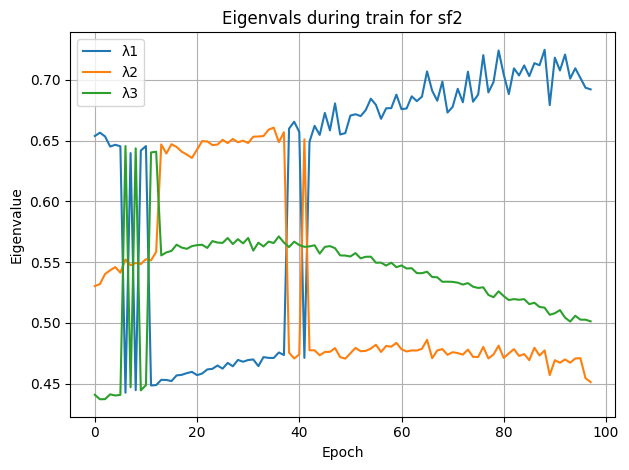

In [23]:
for i in range(train_eigvals.shape[1]):
    plt.plot(train_eigvals[:, i], label=f'λ{i+1}')

plt.xlabel('Epoch')
plt.ylabel('Eigenvalue')
plt.title(f'Eigenvals during train for {data_name}')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(f"figures/{data_name}/eigenvals_train_gaussian3.png", dpi=300)
plt.show()

In [29]:
pces, cdfs = [], []

with torch.no_grad():
    for x, y in datamodule.test_dataloader():
        x = x.to(config.device)
        y = y.to(config.device)
        dist = model.predict(x)
        pce_values, cdf_values, extra = pce(dist, y, n_samples=100, prerank=prerank, mode='test')
        pces.append(pce_values)
        cdfs.append(cdf_values)
pce_total = torch.stack(pces).mean(dim=0)
cdfs_total = torch.stack(cdfs).mean(dim=0)

# if prerank == 'pca':
#     weights_total = torch.stack(weights).mean(dim=0)
#     pce_total = torch.sum(pce_total * weights_total)
#     cdfs_total = cdfs_total.mean(dim=0)
# elif prerank == 'marginal':
#     pce_total = pce_total.mean(dim=0)
#     cdfs_total = cdfs_total.mean(dim=0)

In [30]:
print(pce_total.shape)
print(cdfs_total.shape)

torch.Size([1])
torch.Size([1, 100])


In [10]:
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow-green
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
    "#c5b0d5",  # light purple
    "#c49c94",  # light brown
]


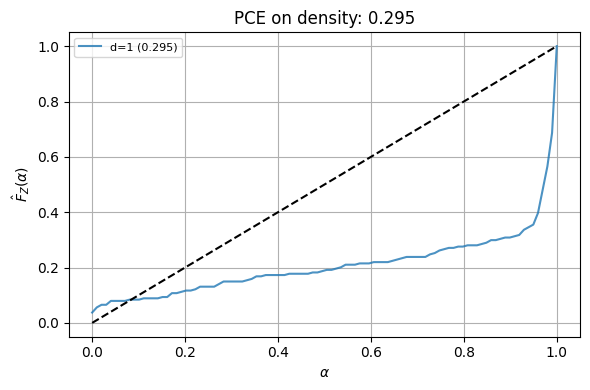

In [31]:
alphas = np.linspace(0, 1, 100)
sorted_indices = torch.argsort(pce_total, descending=True)  # or ascending=False

plt.figure(figsize=(6, 4))
for rank, d in enumerate(sorted_indices):
    d = d.item()
    cdf = cdfs_total[d].cpu().numpy()
    plt.plot(alphas, cdf, color=colors[rank], 
             lw=1.5, alpha=0.8, label=f"d={d+1} ({pce_total[d]:.3f})")

plt.plot(alphas, alphas, linestyle='--', color='black')
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\hat{F}_Z(\alpha)$")
plt.title(f"PCE on {prerank}: {pce_total.mean().item():.3f}")
plt.grid(True)
plt.tight_layout()
plt.legend(loc = 'upper left', fontsize=8)
plt.savefig(f"figures/after-reg/rel_plot_{prerank}_{data_name}_mixgauss.png", dpi=300)
plt.show()